# 01 — Dense nanoGPT baseline ("linear layers")

**Assignment, part 1.** Train a traditional, linear-layer based nanoGPT — the architecture from session 11 —
at a decent size on a decent dataset, and track every metric.

This notebook:

1. prepares the data (GPT-2 BPE tokens, cached as a flat `uint16` file),
2. builds the dense model and accounts for every parameter and FLOP,
3. runs sanity checks (initial loss ≈ ln V, can the model overfit one batch?),
4. trains it, logging to **Aim**,
5. plots the full set of training curves and samples some text.

The trained model is saved to `checkpoints/dense.pt`. It is the starting point of the MoE conversion in notebook 03,
and also the loss reference for the MoE-from-scratch run in notebook 02.

| notebook | what it does |
|---|---|
| **01 (this one)** | dense baseline |
| 02 | MoE layer from first principles + MoE trained from scratch |
| 03 | **convert the trained dense model into an MoE and keep training** |
| 04 | side-by-side analysis, routing / expert specialisation, verdict |

In [1]:
import json
import math
import os
import sys
import time
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, os.environ.get("MOE_SRC", os.path.abspath("../src")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from moe.analysis import make_decoder, make_encoder
from moe.config import get_config
from moe.data import load_dataset_tokens
from moe.model import GPT, GPTConfig, MoEMLP, param_report
from moe.runs import dense_config, flops_per_token, moe_config, train_config
from moe.trainer import load_history, load_model, lr_at, train
from moe.upcycle import max_logit_diff, upcycle
from moe.utils import (
    aim_repo,
    ckpt_dir,
    get_device,
    is_smoke,
    plot_style,
    results_dir,
    savefig,
    set_seed,
    work_root,
)
from moe.viz import color, ema, heatmap_load

plot_style()
X = get_config()
DEVICE = get_device()
torch.set_float32_matmul_precision("high")
set_seed(X.seed)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

print(
    f"torch {torch.__version__} | device = {DEVICE}"
    + (
        f" ({torch.cuda.get_device_name(0)}, {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB)"
        if DEVICE == "cuda"
        else ""
    )
)
print(f"preset = {X.name!r}   (override with MOE_PRESET=smoke|small|base)")
print(f"Aim repo : {aim_repo()}   -> browse with:  uv run aim up")
print()
print(pd.Series(X.to_dict(), name="value").to_string())

torch 2.6.0+cu124 | device = cuda:1
preset = 'base'   (override with MOE_PRESET=smoke|small|base)
Aim repo : /home/ravi.naik/learning/era/ERA/v5/session14/moe_experiments   -> browse with:  uv run aim up

name                    base
vocab_size             50304
block_size               512
n_layer                    8
n_head                     8
n_embd                   512
dropout                  0.0
bias                    True
n_experts                  8
top_k                      2
moe_every                  2
score_fn             softmax
lb_coef               0.0001
bias_update            0.001
z_coef                 0.001
explore_steps            300
explore_noise            1.0
batch_size                32
dense_steps             6000
dense_lr              0.0006
dense_warmup             300
cont_steps              3000
cont_lr               0.0003
cont_warmup              100
min_lr_frac              0.1
weight_decay             0.1
eval_interval            250
eval_iters  

## 1. Data

Tokens are produced once with the GPT-2 byte-pair encoder and stored as a flat array of `uint16`.
Batches are random contiguous windows of `block_size + 1` tokens: inputs are `x = w[:-1]`, targets `y = w[1:]`.

In [2]:
data = load_dataset_tokens(X.dataset)
meta = json.load(open(data.data_dir / "meta.json"))
print("dataset      :", meta["dataset"])
print("tokenizer    :", meta["tokenizer"])
print("vocab size   :", meta["vocab_size"], "-> model vocab (padded) =", X.vocab_size)
print(f"train tokens : {data.num_tokens('train'):,}")
print(f"val tokens   : {data.num_tokens('val'):,}")

tok_per_step = X.batch_size * X.block_size
dense_tokens = X.dense_steps * tok_per_step
print(f"\ntokens / step         : {X.batch_size} x {X.block_size} = {tok_per_step:,}")
print(
    f"dense pre-training    : {X.dense_steps} steps = {dense_tokens / 1e6:.1f}M tokens "
    f"= {dense_tokens / data.num_tokens('train'):.2f} epochs of the train split"
)
cont_tokens = X.cont_steps * tok_per_step
print(
    f"phase 2 (after MoE)   : {X.cont_steps} steps = {cont_tokens / 1e6:.1f}M further tokens"
)

decode = make_decoder(X.dataset)
print("\n--- first 60 training tokens, decoded ---")
print(repr(decode(data.split_data("train")[:60])))

x, y = data.get_batch("train", 2, 12, "cpu")
print("\n--- what a batch looks like (x row, y row) ---")
print("x[0]:", x[0].tolist())
print("y[0]:", y[0].tolist())
assert (x[:, 1:] == y[:, :-1]).all()
print("targets are inputs shifted by one: OK")

[data] cached wikitext103: 119,085,169 train / 249,750 val tokens
dataset      : wikitext-103-raw-v1
tokenizer    : gpt2-bpe
vocab size   : 50257 -> model vocab (padded) = 50304
train tokens : 119,085,169
val tokens   : 249,750

tokens / step         : 32 x 512 = 16,384
dense pre-training    : 6000 steps = 98.3M tokens = 0.83 epochs of the train split
phase 2 (after MoE)   : 3000 steps = 49.2M further tokens

--- first 60 training tokens, decoded ---
' = Valkyria Chronicles III = \n<|endoftext|> Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III'

--- what a batch looks like (x row, y row) ---
x[0]: [257, 838, 2488, 12, 31, 966, 5046, 764, 35193, 1807, 366, 1012]
y[0]: [838, 2488, 12, 31, 966, 5046, 764, 35193, 1807, 366, 1012, 499]
targets are inputs shifted by one: OK


top    161 tokens cover 50% of the text
top  8,470 tokens cover 90% of the text
top 26,942 tokens cover 99% of the text
  saved assets/01_token_zipf.png


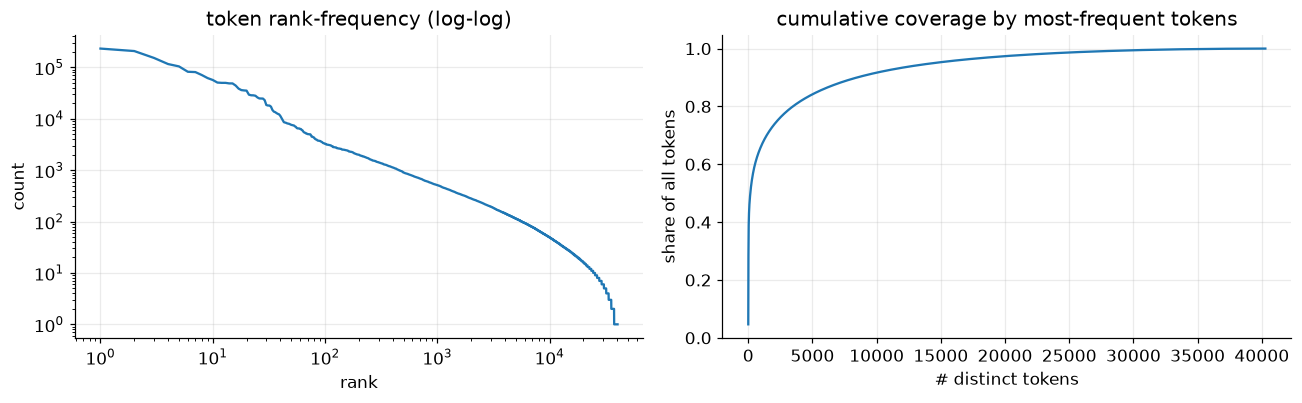

In [3]:
# Zipf check: a handful of tokens dominate -> the loss is dominated by a long tail
sample = np.asarray(
    data.split_data("train")[: min(5_000_000, data.num_tokens("train"))]
)
counts = np.bincount(sample, minlength=X.vocab_size)
srt = np.sort(counts[counts > 0])[::-1]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].loglog(np.arange(1, len(srt) + 1), srt)
ax[0].set_title("token rank-frequency (log-log)")
ax[0].set_xlabel("rank")
ax[0].set_ylabel("count")
cum = np.cumsum(srt) / srt.sum()
ax[1].plot(cum)
ax[1].set_title("cumulative coverage by most-frequent tokens")
ax[1].set_xlabel("# distinct tokens")
ax[1].set_ylabel("share of all tokens")
for q in (0.5, 0.9, 0.99):
    k = int(np.searchsorted(cum, q)) + 1
    print(f"top {k:>6,} tokens cover {q:.0%} of the text")
plt.tight_layout()
savefig(fig, "01_token_zipf.png")
plt.show()

## 2. The model — every parameter accounted for

Pre-LN GPT: token + learned position embeddings, `n_layer` blocks of (LayerNorm → causal attention) and
(LayerNorm → **MLP**), final LayerNorm, tied output head. The MLP is the part that MoE will replace:
`Linear(d, 4d) → GELU → Linear(4d, d)`.

GPTConfig(vocab_size=50257, block_size=512, n_layer=8, n_head=8, n_embd=512, dropout=0.0, bias=True, n_experts=1, top_k=2, moe_every=2, score_fn='softmax')



total parameters: 51,213,824  (51.21M)
                          params  share %
token_embedding (tied)  25731584    50.24
dense_mlp               16797696    32.80
attention                8404992    16.41
position_embedding        262144     0.51
layernorm                  17408     0.03

approx. training FLOPs / token : 330.9 MFLOPs  (6 * matmul params + attention scores)
approx. FLOPs for the dense run : 3.25e+16
  saved assets/01_dense_params.png


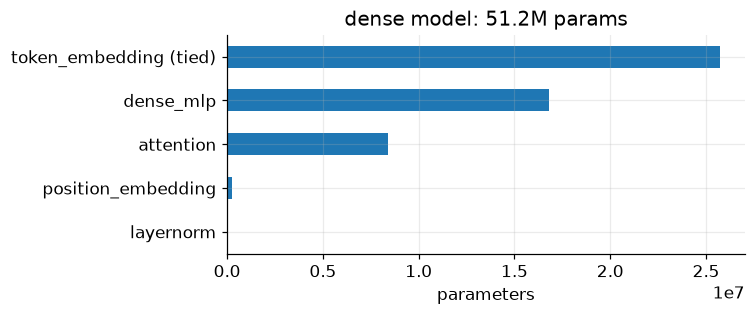

In [4]:
dcfg = dense_config(X, data.vocab_size)
print(dcfg)
model = GPT(dcfg)
rp = param_report(model)
print(f"\ntotal parameters: {rp['total']:,}  ({rp['total'] / 1e6:.2f}M)")
df = pd.DataFrame({"params": rp["groups"]})
df["share %"] = 100 * df["params"] / rp["total"]
print(df.sort_values("params", ascending=False).round(2).to_string())

fl = flops_per_token(model)
print(
    f"\napprox. training FLOPs / token : {fl / 1e6:.1f} MFLOPs  (6 * matmul params + attention scores)"
)
print(f"approx. FLOPs for the dense run : {fl * dense_tokens:.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
df["params"].sort_values().plot.barh(ax=ax, color="#1f77b4")
ax.set_xlabel("parameters")
ax.set_title(f"dense model: {rp['total'] / 1e6:.1f}M params")
plt.tight_layout()
savefig(fig, "01_dense_params.png")
plt.show()

## 3. Sanity checks before spending GPU hours

* A freshly initialised model should predict ~uniformly, so the loss should be ≈ `ln(vocab)`.
* It should be able to **memorise a single batch** — if it can't, something in the model/optimiser is broken.

In [5]:
set_seed(X.seed)
m = GPT(dcfg).to(DEVICE)
xb, yb = data.get_batch("train", X.batch_size, X.block_size, DEVICE)
with torch.no_grad():
    _, l0, _ = m(xb, yb)
print(
    f"initial loss {l0.item():.4f}   vs   ln(vocab) = {math.log(meta['vocab_size']):.4f}"
)

opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
losses = []
for i in range(40):
    _, l, _ = m(xb, yb)
    opt.zero_grad()
    l.backward()
    opt.step()
    losses.append(l.item())
    if i % 10 == 0 or i == 39:
        print(f"  overfit-one-batch step {i:2d}: loss {l.item():.4f}")
print("overfit works:", losses[-1] < 0.5 * losses[0])
del m, opt
if DEVICE == "cuda":
    torch.cuda.empty_cache()

initial loss 10.9107   vs   ln(vocab) = 10.8249
  overfit-one-batch step  0: loss 10.9107
  overfit-one-batch step 10: loss 6.9477
  overfit-one-batch step 20: loss 6.8500
  overfit-one-batch step 30: loss 6.8007
  overfit-one-batch step 39: loss 6.7866
overfit works: False


## 4. Learning-rate schedule

Linear warm-up, then cosine decay to 10 % of the peak. AdamW (β = 0.9 / 0.95), weight decay 0.1 on matrices only,
gradient clipping at 1.0, bf16 autocast on GPU.

  saved assets/01_lr_schedule.png


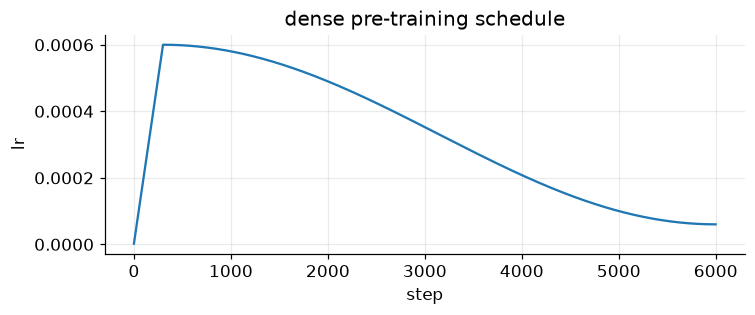

peak lr 6.00e-04 at step 299, final lr 6.00e-05


In [6]:
tc = train_config(
    X, "dense", "dense", X.dense_steps, X.dense_lr, X.dense_warmup, device=DEVICE
)
lrs = [lr_at(s, tc) for s in range(tc.total_steps)]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(lrs)
ax.set_xlabel("step")
ax.set_ylabel("lr")
ax.set_title("dense pre-training schedule")
plt.tight_layout()
savefig(fig, "01_lr_schedule.png")
plt.show()
print(f"peak lr {max(lrs):.2e} at step {int(np.argmax(lrs))}, final lr {lrs[-1]:.2e}")

## 5. Train the dense model

Everything goes to Aim (loss, perplexity, lr, grad-norm, tokens/s) and to `results/dense.json`.
If `checkpoints/dense.pt` is already marked finished, the cell just reloads it, so the notebook is safely re-runnable;
an interrupted run resumes from its last checkpoint.

In [7]:
set_seed(X.seed)
model = GPT(dcfg)
model, H = train(
    model,
    data,
    tc,
    experiment="session14",
    aim_repo=aim_repo(),
    extra_hparams={"arch": "dense", "stage": "pretrain"},
)
print("\nsaved:", os.path.join(ckpt_dir(), "dense.pt"))

[dense] 51.21M params (51.21M active/token) | 6000 steps x 16,384 tok = 98.3M tokens | lr 0.0006 | amp=bf16 | device=cuda:1
  step     0 | train 10.9186 | val 10.9194 (ppl 55235.0)
  step   250 | train 6.0153 | val 5.9727 (ppl 392.6)
  step   500 | train 5.4450 | val 5.3759 (ppl 216.1)
  step   750 | train 5.0579 | val 4.9889 (ppl 146.8)
  step  1000 | train 4.8081 | val 4.7521 (ppl 115.8)
  step  1250 | train 4.6249 | val 4.5643 (ppl 96.0)
  step  1500 | train 4.4633 | val 4.4091 (ppl 82.2)
  step  1750 | train 4.3230 | val 4.2852 (ppl 72.6)
  step  2000 | train 4.2208 | val 4.1797 (ppl 65.3)
  step  2250 | train 4.1423 | val 4.1007 (ppl 60.4)
  step  2500 | train 4.0783 | val 4.0383 (ppl 56.7)
  step  2750 | train 4.0154 | val 3.9779 (ppl 53.4)
  step  3000 | train 3.9627 | val 3.9198 (ppl 50.4)
  step  3250 | train 3.9180 | val 3.8767 (ppl 48.3)
  step  3500 | train 3.8762 | val 3.8428 (ppl 46.7)
  step  3750 | train 3.8375 | val 3.8058 (ppl 45.0)
  step  4000 | train 3.8008 | val 3

## 6. Training curves

  saved assets/01_dense_curves.png


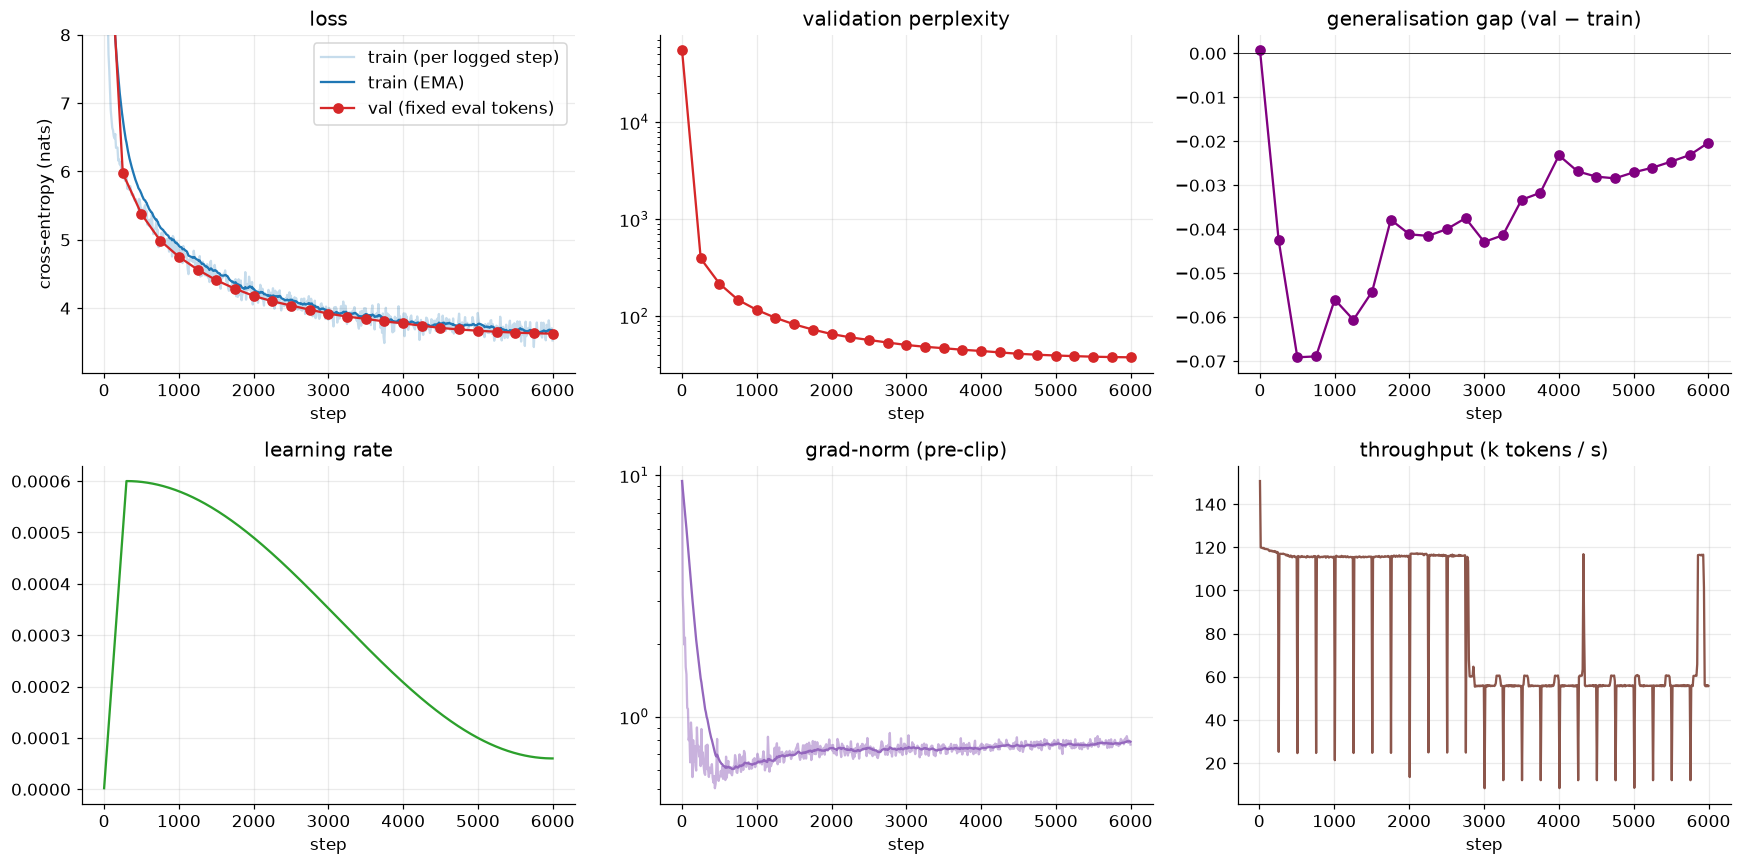

 step   train     val    val_ppl    Δval
    0 10.9186 10.9194 55234.9844     NaN
  250  6.0153  5.9727   392.5738 -4.9466
  500  5.4450  5.3759   216.1271 -0.5969
  750  5.0579  4.9889   146.7812 -0.3869
 1000  4.8081  4.7521   115.8279 -0.2368
 1250  4.6249  4.5643    95.9906 -0.1879
 1500  4.4633  4.4091    82.1917 -0.1552
 1750  4.3230  4.2852    72.6147 -0.1239
 2000  4.2208  4.1797    65.3436 -0.1055
 2250  4.1423  4.1007    60.3845 -0.0789
 2500  4.0783  4.0383    56.7301 -0.0624
 2750  4.0154  3.9779    53.4061 -0.0604
 3000  3.9627  3.9198    50.3922 -0.0581
 3250  3.9180  3.8767    48.2629 -0.0432
 3500  3.8762  3.8428    46.6579 -0.0338
 3750  3.8375  3.8058    44.9597 -0.0371
 4000  3.8008  3.7776    43.7112 -0.0282
 4250  3.7700  3.7431    42.2297 -0.0345
 4500  3.7389  3.7109    40.8901 -0.0322
 4750  3.7162  3.6877    39.9543 -0.0232
 5000  3.6967  3.6697    39.2384 -0.0181
 5250  3.6804  3.6544    38.6449 -0.0152
 5500  3.6660  3.6413    38.1426 -0.0131
 5750  3.6553  3

In [8]:
H = load_history("dense")
steps = np.array(H["step"])
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

ax = axs[0, 0]
ax.plot(steps, H["loss"], alpha=0.25, color="#1f77b4", label="train (per logged step)")
ax.plot(steps, ema(H["loss"], 0.1), color="#1f77b4", label="train (EMA)")
ax.plot(
    H["eval_step"],
    H["val_loss"],
    "o-",
    color="#d62728",
    label="val (fixed eval tokens)",
)
ax.set_title("loss")
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy (nats)")
ax.legend()
ax.set_ylim(top=min(max(H["loss"]), 8))

ax = axs[0, 1]
ax.plot(H["eval_step"], np.exp(H["val_loss"]), "o-", color="#d62728")
ax.set_yscale("log")
ax.set_title("validation perplexity")
ax.set_xlabel("step")

ax = axs[0, 2]
gap = np.array(H["val_loss"]) - np.array(H["train_loss"])
ax.plot(H["eval_step"], gap, "o-", color="purple")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("generalisation gap (val − train)")
ax.set_xlabel("step")

axs[1, 0].plot(steps, H["lr"], color="#2ca02c")
axs[1, 0].set_title("learning rate")
axs[1, 0].set_xlabel("step")
axs[1, 1].plot(steps, H["grad_norm"], color="#9467bd", alpha=0.5)
axs[1, 1].plot(steps, ema(H["grad_norm"], 0.1), color="#9467bd")
axs[1, 1].set_title("grad-norm (pre-clip)")
axs[1, 1].set_xlabel("step")
axs[1, 1].set_yscale("log")
axs[1, 2].plot(steps[1:], np.array(H["tok_s"][1:]) / 1e3, color="#8c564b")
axs[1, 2].set_title("throughput (k tokens / s)")
axs[1, 2].set_xlabel("step")
plt.tight_layout()
savefig(fig, "01_dense_curves.png")
plt.show()

ev = pd.DataFrame(
    {"step": H["eval_step"], "train": H["train_loss"], "val": H["val_loss"]}
)
ev["val_ppl"] = np.exp(ev["val"])
ev["Δval"] = ev["val"].diff()
print(ev.round(4).to_string(index=False))

## 7. Does it speak?

In [9]:
enc, dec = make_encoder(X.dataset), make_decoder(X.dataset)
model = load_model(os.path.join(ckpt_dir(), "dense.pt"), DEVICE)
for prompt in ["The history of the", "In 1999, the city"]:
    ids = torch.tensor([enc(prompt)], device=DEVICE)
    set_seed(0)
    out = model.generate(ids, 60 if not is_smoke() else 5, temperature=0.8, top_k=40)
    print(f"[{prompt}]  ->  {dec(out[0].tolist())!r}\n")

[The history of the]  ->  'The history of the day is not known . \n<|endoftext|> The current period during the 9th century was the first phase of the civil wars , and the period during the 8th century was mainly spent on the coast islands , the Western Isles and the Western Isles . The first phase of the 13th century was completed from'

[In 1999, the city]  ->  'In 1999, the city was split into two different counties . The county has been divided into five counties from the county . The county has served as a county of the county , with its county of P. C. W. , the county seat of P. W. W. . A county is county @-@ county'



## 8. Summary

In [10]:
rp = param_report(model)
summary = pd.Series(
    {
        "parameters": f"{rp['total'] / 1e6:.2f}M",
        "tokens trained": f"{dense_tokens / 1e6:.1f}M",
        "final train loss": round(H["final_train_loss"], 4),
        "final val loss": round(H["final_val_loss"], 4),
        "final val perplexity": round(math.exp(H["final_val_loss"]), 2),
        "wall-clock": f"{H['wall_clock_s'] / 60:.1f} min",
        "mean throughput": f"{np.mean(H['tok_s'][1:]) / 1e3:.0f}k tok/s",
        "peak GPU memory": None
        if H["peak_mem_gb"] is None
        else f"{H['peak_mem_gb']:.1f} GB",
    },
    name="dense baseline",
)
print(summary.to_string())
print("\nNext: 02_moe_from_scratch.ipynb  ->  03_dense_to_moe_upcycling.ipynb")

parameters                 51.21M
tokens trained              98.3M
final train loss           3.6472
final val loss             3.6269
final val perplexity         37.6
wall-clock               25.4 min
mean throughput         83k tok/s
peak GPU memory            0.0 GB

Next: 02_moe_from_scratch.ipynb  ->  03_dense_to_moe_upcycling.ipynb
